# Baseline models

This section estimates baseline association models using the complete-case national panel.

## Setup and data

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style='whitegrid')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

panel = pd.read_csv(PROJECT_ROOT / 'data' / 'processed' / 'panel_skeleton.csv')
controls = [
    'gdp_per_capita_eur',
    'unemployment_rate_pc',
    'poverty_or_social_exclusion_pc',
    'government_health_expenditure_gdp_pc',
    'compulsory_health_financing_gdp_pc',
]
panel['country'] = panel['geo']
panel['year'] = panel['year'].astype(int)

# prepare complete-case panel for baseline model
model_data = panel[['country', 'year', 'unmet_need_pc'] + controls].dropna().copy()
model_data['log_gdp_per_capita'] = np.log(model_data['gdp_per_capita_eur'])
pd.DataFrame({
    'complete_case_rows': [len(model_data)],
    'countries': [model_data['country'].nunique()],
    'years': [model_data['year'].nunique()],
    'first_year': [model_data['year'].min()],
    'last_year': [model_data['year'].max()],
})

,complete_case_rows,countries,years,first_year,last_year
0,282,30,10,2015,2024


In [2]:
model_data.head()

,country,year,unmet_need_pc,gdp_per_capita_eur,unemployment_rate_pc,poverty_or_social_exclusion_pc,government_health_expenditure_gdp_pc,compulsory_health_financing_gdp_pc,log_gdp_per_capita
14,AT,2015,0.1,39640.0,6.1,16.9,8.3,7.74,10.587594
15,AT,2016,0.2,40690.0,6.5,17.2,8.3,7.71,10.613738
16,AT,2017,0.2,41760.0,5.9,17.1,8.3,7.74,10.639694
17,AT,2018,0.1,43360.0,5.2,16.8,8.3,7.78,10.677293
18,AT,2019,0.3,44570.0,4.8,16.5,8.4,7.91,10.704816


## Transformations and descriptive checks

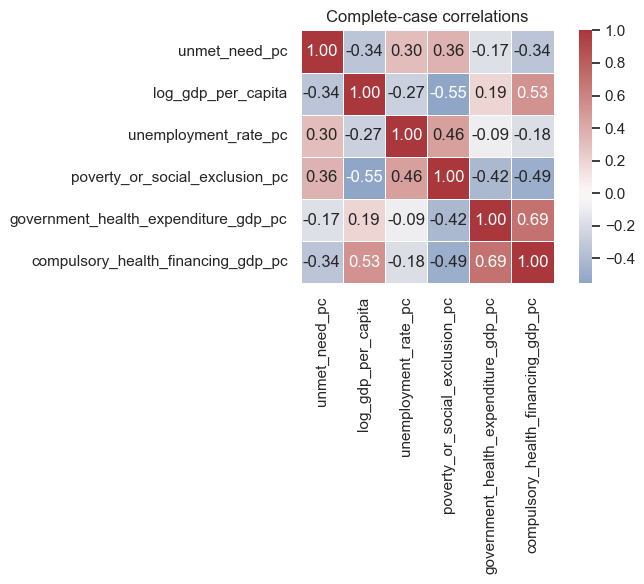

,unmet_need_pc,log_gdp_per_capita,unemployment_rate_pc,poverty_or_social_exclusion_pc,government_health_expenditure_gdp_pc,compulsory_health_financing_gdp_pc
unmet_need_pc,1.000000,-0.335952,0.304893,0.358827,-0.171689,-0.340646
log_gdp_per_capita,-0.335952,1.000000,-0.270915,-0.553327,0.188531,0.527700
unemployment_rate_pc,0.304893,-0.270915,1.000000,0.457477,-0.092787,-0.181973
poverty_or_social_exclusion_pc,0.358827,-0.553327,0.457477,1.000000,-0.416160,-0.486738
government_health_expenditure_gdp_pc,-0.171689,0.188531,-0.092787,-0.416160,1.000000,0.694674
compulsory_health_financing_gdp_pc,-0.340646,0.527700,-0.181973,-0.486738,0.694674,1.000000


In [3]:
standardize_columns = [
    'log_gdp_per_capita',
    'unemployment_rate_pc',
    'poverty_or_social_exclusion_pc',
    'government_health_expenditure_gdp_pc',
    'compulsory_health_financing_gdp_pc',
]
for column in standardize_columns:
    model_data[f'std_{column}'] = (model_data[column] - model_data[column].mean()) / model_data[column].std(ddof=0)

corr_vars = ['unmet_need_pc'] + standardize_columns
model_corr = model_data[corr_vars].corr(method='pearson')
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(model_corr, annot=True, fmt='.2f', cmap='vlag', center=0, square=True, linewidths=0.4, ax=ax)
ax.set_title('Complete-case correlations')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'model_correlations_heatmap.png', dpi=180)
plt.show()
model_corr

## Baseline pooled model

In [4]:
main_terms = [
    'log_gdp_per_capita',
    'unemployment_rate_pc',
    'poverty_or_social_exclusion_pc',
    'government_health_expenditure_gdp_pc',
    'compulsory_health_financing_gdp_pc',
]
formula = 'unmet_need_pc ~ ' + ' + '.join(main_terms) + ' + C(year)'
pooled_model = smf.ols(formula=formula, data=model_data)
pooled_result = pooled_model.fit(cov_type='cluster', cov_kwds={'groups': model_data['country']})
pooled_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          unmet_need_pc   R-squared:                       0.221
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     3.257
Date:                Thu, 14 May 2026   Prob (F-statistic):            0.00350
Time:                        14:48:52   Log-Likelihood:                -669.71
No. Observations:                 282   AIC:                             1369.
Df Residuals:                     267   BIC:                             1424.
Df Model:                          14                                         
Covariance Type:              cluster                                         
========================================================================================================
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
Intercept                                7.3898      6.813      1.085      0.278      -5.963      20.743
C(year)[T.2016]                         -0.0326      0.241     -0.135      0.892      -0.504       0.439
C(year)[T.2017]                         -0.4276      0.416     -1.028      0.304      -1.243       0.388
C(year)[T.2018]                          0.0001      0.493      0.000      1.000      -0.965       0.965
C(year)[T.2019]                          0.0255      0.559      0.046      0.964      -1.070       1.121
C(year)[T.2020]                         -0.1359      0.470     -0.289      0.773      -1.057       0.786
C(year)[T.2021]                         -0.1706      0.553     -0.308      0.758      -1.255       0.914
C(year)[T.2022]                          0.2416      0.733      0.330      0.742      -1.195       1.678
C(year)[T.2023]                          0.8045      0.772      1.042      0.297      -0.709       2.318
C(year)[T.2024]                          0.8027      0.630      1.275      0.202      -0.432       2.037
log_gdp_per_capita                      -0.5457      0.593     -0.920      0.358      -1.708       0.617
unemployment_rate_pc                     0.1602      0.186      0.861      0.389      -0.205       0.525
poverty_or_social_exclusion_pc           0.0617      0.065      0.955      0.340      -0.065       0.189
government_health_expenditure_gdp_pc     0.1588      0.190      0.835      0.404      -0.214       0.532
compulsory_health_financing_gdp_pc      -0.4010      0.243     -1.652      0.099      -0.877       0.075
==============================================================================
Omnibus:                      135.371   Durbin-Watson:                   0.369
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              647.203
Skew:                           1.986   Prob(JB):                    2.90e-141
Kurtosis:                       9.269   Cond. No.                         671.
==============================================================================

Notes:
[1] Standard Errors are robust to cluster correlation (cluster)
"""

In [5]:
def tidy_result(result, keep_terms=None):
    table = pd.DataFrame({
        'variable': result.params.index,
        'estimate': result.params.values,
        'standard_error': result.bse.values,
        't_stat': result.tvalues.values,
        'p_value': result.pvalues.values,
    })
    if keep_terms is not None:
        table = table.loc[table['variable'].isin(keep_terms)].copy()
    return table.round(4)

pooled_table = tidy_result(pooled_result)
pooled_table.to_csv(OUTPUTS_DIR / 'table_pooled_baseline.csv', index=False)
pooled_table

,variable,estimate,standard_error,t_stat,p_value
0,Intercept,7.3898,6.8130,1.0847,0.2781
1,C(year)[T.2016],-0.0326,0.2408,-0.1354,0.8923
2,C(year)[T.2017],-0.4276,0.4160,-1.0279,0.3040
3,C(year)[T.2018],0.0001,0.4925,0.0002,0.9998
4,C(year)[T.2019],0.0255,0.5590,0.0456,0.9637
5,C(year)[T.2020],-0.1359,0.4702,-0.2891,0.7725
6,C(year)[T.2021],-0.1706,0.5532,-0.3084,0.7578
7,C(year)[T.2022],0.2416,0.7329,0.3297,0.7416
8,C(year)[T.2023],0.8045,0.7721,1.0420,0.2974
9,C(year)[T.2024],0.8027,0.6298,1.2745,0.2025


In [6]:
def direction_text(value):
    if value > 0:
        return 'positive'
    if value < 0:
        return 'negative'
    return 'near zero'

coef = pooled_result.params
lines = [
    '# Pooled baseline summary',
    '',
    f'The pooled baseline uses {int(pooled_result.nobs)} complete country-year rows from {model_data["country"].nunique()} countries.',
    f'The model includes year indicators and clustered standard errors by country. The R-squared is {pooled_result.rsquared:.3f}.',
    '',
    'Main coefficient patterns:',
]
for term in main_terms:
    lines.append(f'- `{term}` has a {direction_text(coef[term])} association. The estimate is {coef[term]:.3f}.')
lines.extend([
    '',
    'The coefficients describe aggregate associations in the complete-case Eurostat panel.',
    'They should not be read as evidence about cause and result.',
])
(OUTPUTS_DIR / 'pooled_baseline_summary.md').write_text('\n'.join(lines) + '\n', encoding='utf-8')
'\n'.join(lines)

'# Pooled baseline summary\n\nThe pooled baseline uses 282 complete country-year rows from 30 countries.\nThe model includes year indicators and clustered standard errors by country. The R-squared is 0.221.\n\nMain coefficient patterns:\n- `log_gdp_per_capita` has a negative association. The estimate is -0.546.\n- `unemployment_rate_pc` has a positive association. The estimate is 0.160.\n- `poverty_or_social_exclusion_pc` has a positive association. The estimate is 0.062.\n- `government_health_expenditure_gdp_pc` has a positive association. The estimate is 0.159.\n- `compulsory_health_financing_gdp_pc` has a negative association. The estimate is -0.401.\n\nThe coefficients describe aggregate associations in the complete-case Eurostat panel.\nThey should not be read as evidence about cause and result.'

## Country and year indicator extension

In [7]:
country_counts = model_data.groupby('country')['year'].nunique()
fe_feasible = (len(model_data) >= 150) and (model_data['country'].nunique() >= 20) and ((country_counts >= 8).mean() >= 0.75)
pd.DataFrame({
    'complete_case_rows': [len(model_data)],
    'countries': [model_data['country'].nunique()],
    'share_countries_with_at_least_8_years': [round(float((country_counts >= 8).mean()), 3)],
    'indicator_extension_feasible': [fe_feasible],
})

,complete_case_rows,countries,share_countries_with_at_least_8_years,indicator_extension_feasible
0,282,30,0.967,True


In [8]:
if fe_feasible:
    indicator_formula = 'unmet_need_pc ~ ' + ' + '.join(main_terms) + ' + C(country) + C(year)'
    indicator_model = smf.ols(formula=indicator_formula, data=model_data)
    indicator_result = indicator_model.fit(cov_type='cluster', cov_kwds={'groups': model_data['country']})
    fe_table = tidy_result(indicator_result, keep_terms=main_terms)
    fe_table.to_csv(OUTPUTS_DIR / 'table_fe_baseline.csv', index=False)
else:
    indicator_result = None
    fe_table = pd.DataFrame(columns=['variable', 'estimate', 'standard_error', 't_stat', 'p_value'])
    fe_table.to_csv(OUTPUTS_DIR / 'table_fe_baseline.csv', index=False)
fe_table

,variable,estimate,standard_error,t_stat,p_value
39,log_gdp_per_capita,-1.0414,2.2015,-0.4730,0.6362
40,unemployment_rate_pc,-0.0337,0.0866,-0.3893,0.6970
41,poverty_or_social_exclusion_pc,0.1775,0.0672,2.6412,0.0083
42,government_health_expenditure_gdp_pc,-0.2290,0.4464,-0.5130,0.6080
43,compulsory_health_financing_gdp_pc,0.0974,0.4441,0.2193,0.8264


In [9]:
if indicator_result is not None:
    pooled_main = pooled_table.loc[pooled_table['variable'].isin(main_terms), ['variable', 'estimate']].rename(columns={'estimate': 'pooled_estimate'})
    fe_main = fe_table[['variable', 'estimate']].rename(columns={'estimate': 'indicator_estimate'})
    compare = pooled_main.merge(fe_main, on='variable', how='inner')
    compare['change'] = compare['indicator_estimate'] - compare['pooled_estimate']
    lines = [
        '# Country and year indicator summary',
        '',
        f'The indicator extension uses {int(indicator_result.nobs)} complete country-year rows from {model_data["country"].nunique()} countries.',
        f'The model includes country and year indicators. The R-squared is {indicator_result.rsquared:.3f}.',
        '',
        'Control coefficient patterns compared with the pooled model:',
    ]
    for _, row in compare.iterrows():
        lines.append(
            f'- `{row["variable"]}` changes from {row["pooled_estimate"]:.3f} in the pooled model to {row["indicator_estimate"]:.3f} in the indicator model.'
        )
    lines.extend([
        '',
        'The estimates remain descriptive associations in aggregate country-year data.',
        'They should not be read as evidence about cause and result.',
    ])
else:
    lines = [
        '# Country and year indicator summary',
        '',
        'The complete-case panel is too thin for this extension under the feasibility rule used here.',
        'The pooled model is the reported baseline for this phase.',
    ]
(OUTPUTS_DIR / 'fe_baseline_summary.md').write_text('\n'.join(lines) + '\n', encoding='utf-8')
'\n'.join(lines)

'# Country and year indicator summary\n\nThe indicator extension uses 282 complete country-year rows from 30 countries.\nThe model includes country and year indicators. The R-squared is 0.895.\n\nControl coefficient patterns compared with the pooled model:\n- `log_gdp_per_capita` changes from -0.546 in the pooled model to -1.041 in the indicator model.\n- `unemployment_rate_pc` changes from 0.160 in the pooled model to -0.034 in the indicator model.\n- `poverty_or_social_exclusion_pc` changes from 0.062 in the pooled model to 0.177 in the indicator model.\n- `government_health_expenditure_gdp_pc` changes from 0.159 in the pooled model to -0.229 in the indicator model.\n- `compulsory_health_financing_gdp_pc` changes from -0.401 in the pooled model to 0.097 in the indicator model.\n\nThe estimates remain descriptive associations in aggregate country-year data.\nThey should not be read as evidence about cause and result.'